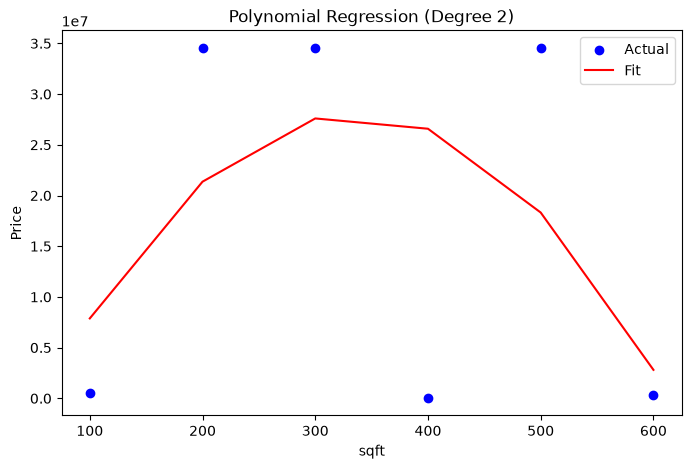

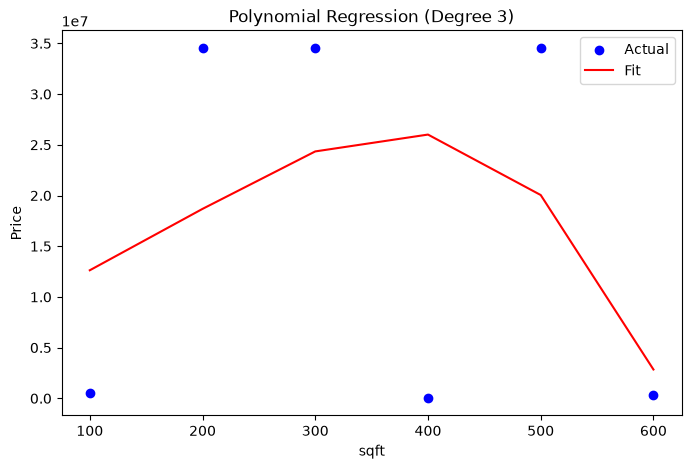

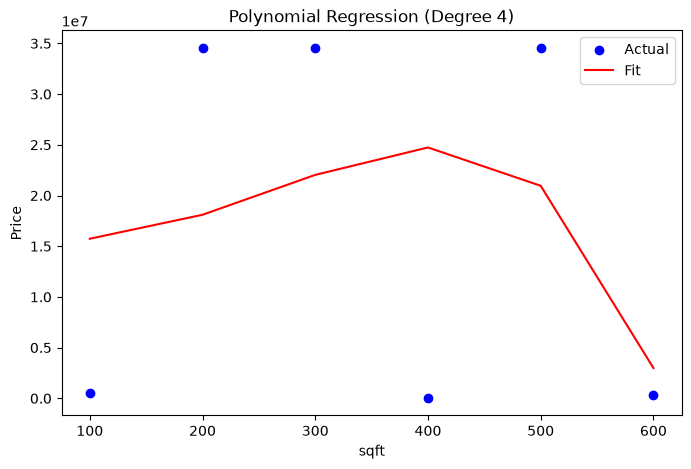

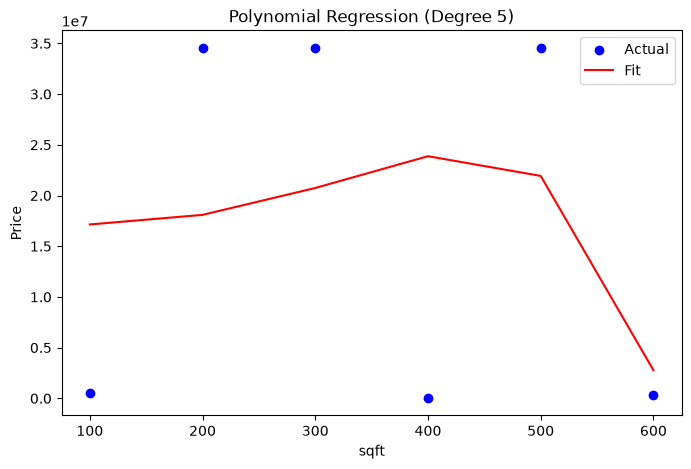

Predicted price for 350 sqft: [25903586.29744711]


/home/gajen/miniconda3/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = pd.DataFrame([100, 200, 300, 400, 500, 600], columns=['sqft'])
y = pd.DataFrame([543543, 34543543, 34543345, 34534, 34543534, 345345], columns=['Price'])

models = {}

for i in [2, 3, 4, 5]:
    poly = PolynomialFeatures(degree=i)
    X_poly = poly.fit_transform(X)
    
    lin = LinearRegression()
    lin.fit(X_poly, y)
    
    # Store both the model AND the poly transformer
    models[i] = {'poly': poly, 'model': lin}
    
    # Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, color='blue', label='Actual')
    plt.plot(X, lin.predict(X_poly), color='red', label='Fit')
    plt.title(f'Polynomial Regression (Degree {i})')
    plt.xlabel('sqft')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Later, use a stored model to predict
test_sqft = 350
poly_transformer = models[3]['poly']  # Get degree 3 transformer
test_X_poly = poly_transformer.transform([[test_sqft]])
prediction = models[3]['model'].predict(test_X_poly)
print(f"Predicted price for {test_sqft} sqft: {prediction[0]}")